# Demo: orquestador multi-agente con Supervisor

Pre-entrega 6. Este notebook muestra el flujo de delegación **ejecutado de verdad** contra Gemini:

1. **Flujo completo**: una consulta que obliga al Supervisor a mandar la tarea al Investigador, pasar el dato al Analista, sintetizar, validar y cerrar.
2. **Ruteo dinámico**: una consulta que la documentación no responde; el Supervisor no sigue un pipeline fijo y se saltea al Analista.

El refinamiento y los cortes del "supervisor infinito", que con un LLM real aparecen solo a veces, están en [`demo_reglas.ipynb`](demo_reglas.ipynb) (corre sin clave de API). Una corrida real con refinamiento quedó en [`docs/corrida_refinamiento.txt`](docs/corrida_refinamiento.txt).

Las llamadas y los tokens son los que reportó la API; los tiempos se miden localmente e incluyen las esperas del limitador de ritmo.

> **Nota:** estas salidas son de la corrida del 24/09 con el commit `6c01b88`. Después se corrigió el validador: ya no toma como evidencia la metadata de las herramientas ni cuenta los dígitos de los nombres de archivo, y rechaza citas a archivos de los que no se recuperó ningún fragmento. Re-validadas con la versión actual, la consulta 1 sigue aprobada (14 números con respaldo en lugar de 16) y la respuesta de la consulta 2 tendría que corregirse, porque cita dos archivos que no se consultaron. El notebook se vuelve a ejecutar con la próxima cuota diaria de la API.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.display import Image, Markdown, display

from config import settings
from graph import build_graph
from knowledge_base import get_store
from main import DEMO_QUESTION, OUT_OF_SCOPE_QUESTION, contributions_table, run_with_trace

print(f'Supervisor y sintetizador: {settings.supervisor_model} · especialistas: {settings.llm_model} · thinking_level={settings.thinking_level}')
print(f'Embeddings: {settings.embedding_model} · ritmo máximo: {settings.llm_rpm} pedidos/min por modelo (capa gratuita)')
store = get_store()
print(f"Base vectorial: {store._collection.count()} fragmentos en la colección '{settings.collection_name}'")
print(f'Límites: {settings.max_steps} decisiones del supervisor, {settings.max_attempts_per_agent} intentos por agente')
graph = build_graph()

Supervisor y sintetizador: gemini-3-flash-preview · especialistas: gemini-3.5-flash-lite · thinking_level=low
Embeddings: gemini-embedding-001 · ritmo máximo: 5 pedidos/min por modelo (capa gratuita)


Base vectorial: 19 fragmentos en la colección 'orbital_docs'
Límites: 8 decisiones del supervisor, 2 intentos por agente


## El grafo

Generado con `graph.get_graph().draw_mermaid_png()`. Las líneas punteadas son las aristas condicionales que salen del Supervisor.

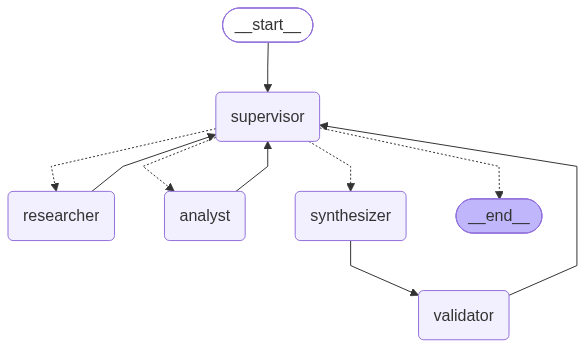

In [2]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:  # sin conexión a mermaid.ink
    print(graph.get_graph().draw_mermaid())

## 1. Flujo completo: investigar → analizar → sintetizar → validar → cerrar

La consulta necesita dos especialidades: **datos** que solo están en la documentación (el manifiesto de `pagos-api`, qué implica blue-green, el límite por pod) y **cálculos** sobre esos datos. Cada bloque de la traza es un nodo del grafo en el orden en que se ejecutó.

In [3]:
print('Consulta:', DEMO_QUESTION, '\n')
result = run_with_trace(graph, DEMO_QUESTION)

Consulta: Tomando el manifiesto de ejemplo de pagos-api de la documentación de Orbital: ¿cuánta CPU y memoria reserva en total cuando escala al máximo de réplicas? ¿Cuánto necesitaría durante una transición blue-green en ese máximo? ¿Cada pod respeta el límite por pod de la plataforma? 



🧭 supervisor · decisión 1 → researcher
   evaluación: Sin aportes
   motivo: Es el primer paso necesario para obtener los datos técnicos antes de realizar cualquier cálculo o síntesis.
   instrucción: Busca el manifiesto de ejemplo de la aplicación 'pagos-api' en la documentación de Orbital. Necesito identificar los valores de 'requests' de CPU y memoria, el número máximo de réplicas (hpa) definido en el ejemplo, y si existe un límite de plataforma por pod para comparar. Por favor, cita los documentos encontrados como [archivo#n].



🔎 researcher · intento 1 · herramientas: search_docs×2 · fragmentos: 03_configuracion_y_secretos.md#2, 02_despliegue_y_cli.md#4, 04_troubleshooting.md#4, 03_configuracion_y_secretos.md#3, 02_despliegue_y_cli.md#1, 01_introduccion_orbital.md#2, 02_despliegue_y_cli.md#0
   │ Hallazgos:
   │ - `cpu: "500m"` [02_despliegue_y_cli.md#4]
   │ - `memory: "512Mi"` [02_despliegue_y_cli.md#4]
   │ - `replicas.max: 10` [02_despliegue_y_cli.md#4]
   │ - "Los valores máximos permitidos por pod son 4 CPU y 8 GiB de memoria" [03_configuracion_y_secretos.md#2]
   │ - "bluegreen: levanta la nueva versión completa en paralelo y conmuta el tráfico de golpe con `orb switch`. Duplica el consumo de recursos durante la transición." [02_despliegue_y_cli.md#1]
   │ 
   │ No encontrado:
   │ - nada



🧭 supervisor · decisión 2 → analyst
   evaluación: La investigación (R1, R2) es exitosa: se obtuvieron los requests de CPU (500m) y memoria (512Mi), el máximo de réplicas (10), los límites de la plataforma (4 CPU, 8 GiB) y el factor multiplicador para blue-green.
   motivo: Se requiere que el analista realice las multiplicaciones para el escalado máximo y la transición blue-green, además de validar los límites por pod.
   instrucción: Realizar los siguientes cálculos basados en los hallazgos: 1) CPU y memoria total para 10 réplicas (500m CPU y 512Mi memoria por réplica). 2) CPU y memoria total necesaria durante una transición blue-green (duplicar el resultado del punto 1). 3) Verificar si los requests por pod (500m CPU, 512Mi memoria) están dentro de los límites de la plataforma (4 CPU, 8 GiB). Convertir unidades si es […]



🧮 analyst · intento 1 · herramientas: calculate×4, convert_units×1
   │ Cálculos:
   │ - CPU total para 10 réplicas: `0.5 * 10` = `5 cores` (datos: 500m CPU por réplica, 10 réplicas)
   │ - Memoria total para 10 réplicas: `512 * 10` = `5120 Mi` (datos: 512Mi memoria por réplica, 10 réplicas)
   │ - CPU total durante transición blue-green: `5 * 2` = `10 cores` (datos: 5 cores de CPU total, duplicar por blue-green)
   │ - Memoria total durante transición blue-green: `5120 * 2` = `10240 Mi` (datos: 5120 Mi de memoria total, duplicar por blue-green)
   │ - Conversión de memoria de pod a Gi: `convert_units("512Mi", "Gi")` = `0.5 Gi` (datos: 512Mi memoria por pod)
   │ Conclusiones:
   │ - Para 10 réplicas se requieren 5 cores de CPU y 5120Mi (5 Gi) de memoria.
   │ - Durante la transición blue-green, el requerimiento asciende a 10 cores de CPU y 10240Mi (~10 Gi) de memoria.
   │ - Los requests por pod (0.5 CPU y 0.5 Gi / 512Mi) están ampliamente dentro de los límites de la plataforma (4 CPU

🧭 supervisor · decisión 3 → synthesizer
   evaluación: La investigación identificó los recursos por pod, el máximo de réplicas y las reglas de blue-green con sus respectivas citas. El analista calculó los totales para el máximo de réplicas y la duplicación por transición, confirmando el cumplimiento de límites.
   motivo: Se cuenta con toda la información necesaria y los cálculos realizados para que el sintetizador redacte la respuesta final.
   instrucción: Redactar la respuesta final indicando que el total reservado para 10 réplicas de 'pagos-api' es de 5 cores de CPU y 5120 Mi de memoria [02_despliegue_y_cli.md#4]. Explicar que durante una transición blue-green este consumo se duplica a 10 cores y 10240 Mi [02_despliegue_y_cli.md#1]. Finalmente, confirmar que cada pod (500m CPU y 512Mi memoria) respeta los límites de la plataforma (4 CPU y 8 […]



✍️  synthesizer · intento 1
   │ Para 10 réplicas del servicio pagos-api, el total reservado es de 5 cores de CPU y 5120 Mi de memoria. Durante una transición blue-green, este consumo se duplica alcanzando los 10 cores y 10240 Mi, mientras que cada pod individual se mantiene dentro de los límites permitidos por la plataforma.
   │ 
   │ Detalle:
   │ - El total reservado para 10 réplicas (máximo configurado) es de 5 cores de CPU y 5120 Mi de memoria [02_despliegue_y_cli.md#4].
   │ - Durante una transición blue-green se duplica el consumo de recursos, requiriendo 10 cores de CPU y 10240 Mi de memoria [02_despliegue_y_cli.md#1].
   │ - Cada pod individual (500m CPU y 512Mi memoria) respeta los límites máximos de la plataforma de 4 CPU y 8 GiB [03_configuracion_y_secretos.md#2].
   │ 
   │ Fuentes: [02_despliegue_y_cli.md], [03_configuracion_y_secretos.md]

🛡️  validator · APROBADA: 16 números con respaldo · citas válidas: 3



🧭 supervisor · decisión 4 → FINISH
   evaluación: El borrador del sintetizador responde todas las partes de la consulta, los cálculos fueron validados por el analista y la validación automática de números y citas es satisfactoria.
   motivo: Se han cumplido todos los objetivos de investigación, análisis y síntesis, y el borrador final pasó la validación automática.



In [4]:
display(Markdown('### Respuesta final\n\n' + result.state['final_answer']))
print(f'{result.usage.summary()} · {result.seconds:.1f} s')

### Respuesta final

Para 10 réplicas del servicio pagos-api, el total reservado es de 5 cores de CPU y 5120 Mi de memoria. Durante una transición blue-green, este consumo se duplica alcanzando los 10 cores y 10240 Mi, mientras que cada pod individual se mantiene dentro de los límites permitidos por la plataforma.

Detalle:
- El total reservado para 10 réplicas (máximo configurado) es de 5 cores de CPU y 5120 Mi de memoria [02_despliegue_y_cli.md#4].
- Durante una transición blue-green se duplica el consumo de recursos, requiriendo 10 cores de CPU y 10240 Mi de memoria [02_despliegue_y_cli.md#1].
- Cada pod individual (500m CPU y 512Mi memoria) respeta los límites máximos de la plataforma de 4 CPU y 8 GiB [03_configuracion_y_secretos.md#2].

Fuentes: [02_despliegue_y_cli.md], [03_configuracion_y_secretos.md]

10 llamadas al LLM · 11.728 tokens de entrada · 1.691 de salida (0 de razonamiento) · 288.2 s


### Estado compartido: quién aportó qué

`state['contributions']` es append-only: cada aporte guarda agente, intento, instrucción recibida, herramientas usadas y evidencia.

In [5]:
display(Markdown(contributions_table(result.state)))
print('Ruta del supervisor:', ' → '.join(d['route'] for d in result.state['decisions']))
print('Validación:', result.state['validation'])

| # | agente | intento | herramientas | fragmentos recuperados | inicio del aporte |
|---|---|---|---|---|---|
| 1 | researcher | 1 | search_docs×2 | 03_configuracion_y_secretos.md#2, 02_despliegue_y_cli.md#4, 04_troubleshooting.md#4, 03_configuracion_y_secretos.md#3, 02_despliegue_y_cli.md#1, 01_introduccion_orbital.md#2, 02_despliegue_y_cli.md#0 | `cpu: "500m"` [02_despliegue_y_cli.md#4] |
| 2 | analyst | 1 | calculate×4, convert_units×1 | — | CPU total para 10 réplicas: `0.5 * 10` = `5 cores` (datos: 500m CPU por… |
| 3 | synthesizer | 1 | — | — | Para 10 réplicas del servicio pagos-api, el total reservado es de 5 cores de… |

Ruta del supervisor: researcher → analyst → synthesizer → FINISH
Validación: {'passed': True, 'checked_numbers': 16, 'unsupported_numbers': [], 'invalid_citations': [], 'cited_sources': ['02_despliegue_y_cli.md#4', '02_despliegue_y_cli.md#1', '03_configuracion_y_secretos.md#2'], 'warnings': []}


## 2. Ruteo dinámico: la documentación no tiene la respuesta

El precio de la licencia no figura en ningún documento. Lo esperable es que el Investigador lo declare como *no encontrado*, que el Supervisor **no** mande nada al Analista (no hay datos para calcular) y que la respuesta lo diga en lugar de inventar un número.

In [6]:
print('Consulta:', OUT_OF_SCOPE_QUESTION, '\n')
result2 = run_with_trace(graph, OUT_OF_SCOPE_QUESTION)
display(Markdown('### Respuesta final\n\n' + result2.state['final_answer']))
print('Ruta del supervisor:', ' → '.join(d['route'] for d in result2.state['decisions']))
print(f'{result2.usage.summary()} · {result2.seconds:.1f} s')

Consulta: ¿Cuánto cuesta por mes la licencia de Orbital para un equipo de 80 desarrolladores? 



🧭 supervisor · decisión 1 → researcher
   evaluación: Sin aportes.
   motivo: Es necesario obtener primero los datos de precios por licencia o por usuario antes de realizar cualquier cálculo de costo total.
   instrucción: Busca en la documentación de Orbital el costo unitario de la licencia de desarrollador y cualquier esquema de precios por volumen o planes mensuales disponibles que apliquen para un equipo de 80 personas. Asegúrate de incluir las citas [archivo#n] de donde provenga la información.



🔎 researcher · intento 1 · herramientas: search_docs×3, list_sources×1 · fragmentos: 01_introduccion_orbital.md#1, 01_introduccion_orbital.md#3, 01_introduccion_orbital.md#2, 04_troubleshooting.md#2, 01_introduccion_orbital.md#0
   │ Hallazgos:
   │ - nada
   │ 
   │ No encontrado:
   │ - El costo unitario de la licencia de desarrollador [01_introduccion_orbital.md#0], [01_introduccion_orbital.md#1], [01_introduccion_orbital.md#2], [01_introduccion_orbital.md#3], [02_despliegue_y_cli.md], [03_configuracion_y_secretos.md], [04_troubleshooting.md]
   │ - Esquemas de precios por volumen o planes mensuales disponibles [01_introduccion_orbital.md#0], [01_introduccion_orbital.md#1], [01_introduccion_orbital.md#2], [01_introduccion_orbital.md#3], [02_despliegue_y_cli.md], [03_configuracion_y_secretos.md], [04_troubleshooting.md]



🧭 supervisor · decisión 2 → synthesizer
   evaluación: El investigador ha verificado exhaustivamente la documentación disponible (01, 02, 03, 04) y ha confirmado que no existe información sobre costos de licencias o planes de precios.
   motivo: Dado que el investigador agotó las fuentes y confirmó que el dato no existe, corresponde al sintetizador informar sobre esta ausencia de información.
   instrucción: Redacta una respuesta informando al usuario que, tras revisar la documentación técnica de Orbital, no se han encontrado datos sobre los costos de licencias, esquemas de precios por volumen ni planes mensuales. Indica que esta información no está disponible en los manuales actuales.



✍️  synthesizer · intento 1
   │ No se encontró información sobre el costo mensual de la licencia de Orbital para un equipo de 80 desarrolladores en la documentación técnica revisada. Actualmente, los manuales no detallan esquemas de precios por volumen ni planes mensuales disponibles.
   │ 
   │ Detalle:
   │ - El costo unitario de la licencia de desarrollador no figura en los documentos de introducción o despliegue [01_introduccion_orbital.md#0], [01_introduccion_orbital.md#1], [01_introduccion_orbital.md#2], [01_introduccion_orbital.md#3], [02_despliegue_y_cli.md].
   │ - No se hallaron datos sobre esquemas de precios por volumen o planes mensuales en los manuales de configuración o resolución de problemas [03_configuracion_y_secretos.md], [04_troubleshooting.md].
   │ 
   │ Fuentes: [01_introduccion_orbital.md], [02_despliegue_y_cli.md], [03_configuracion_y_secretos.md], [04_troubleshooting.md]

🛡️  validator · APROBADA: 8 números con respaldo · citas válidas: 4



🧭 supervisor · decisión 3 → FINISH
   evaluación: La investigación confirmó que los datos de costos no existen en la documentación y el sintetizador ya redactó una respuesta informando esta carencia con la validación aprobada.
   motivo: La consulta ha sido respondida declarando la ausencia de información según la rúbrica (R2 y F2).



### Respuesta final

No se encontró información sobre el costo mensual de la licencia de Orbital para un equipo de 80 desarrolladores en la documentación técnica revisada. Actualmente, los manuales no detallan esquemas de precios por volumen ni planes mensuales disponibles.

Detalle:
- El costo unitario de la licencia de desarrollador no figura en los documentos de introducción o despliegue [01_introduccion_orbital.md#0], [01_introduccion_orbital.md#1], [01_introduccion_orbital.md#2], [01_introduccion_orbital.md#3], [02_despliegue_y_cli.md].
- No se hallaron datos sobre esquemas de precios por volumen o planes mensuales en los manuales de configuración o resolución de problemas [03_configuracion_y_secretos.md], [04_troubleshooting.md].

Fuentes: [01_introduccion_orbital.md], [02_despliegue_y_cli.md], [03_configuracion_y_secretos.md], [04_troubleshooting.md]

Ruta del supervisor: researcher → synthesizer → FINISH
9 llamadas al LLM · 11.857 tokens de entrada · 1.400 de salida (521 de razonamiento) · 225.1 s
